# **CNN Pre-Trained Model**

# Resnet 50

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from PIL import Image

# === CONFIG ===
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 10

# === PATH SETUP ===
BASE_PATH = "/kaggle/input/ocular-disease-recognition-odir5k"
IMAGE_FOLDER = os.path.join(BASE_PATH, "ODIR-5K", "ODIR-5K", "Training Images")
CSV_PATH = "/kaggle/input/ocular-disease-recognition-odir5k/full_df.csv"
WEIGHTS_PATH = "/kaggle/input/resnet/keras/default/1/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5"

# === LOAD DATA ===
df = pd.read_csv(CSV_PATH)
df = df[df['Left-Fundus'].notna()]
df['filename'] = df['Left-Fundus'].str.strip()
df['filepath'] = df['filename'].apply(lambda x: os.path.join(IMAGE_FOLDER, x))
df = df[df['filepath'].apply(os.path.exists)]

# === PROCESS LABELS ===
label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']  # Update to your actual label cols
df[label_cols] = df[label_cols].fillna(0).astype(int)
df['label_list'] = df[label_cols].apply(lambda row: [col for col in label_cols if row[col] == 1], axis=1)

# Remove rows with very rare labels (avoid stratify crash)
from collections import Counter
flat_labels = [label for sublist in df['label_list'] for label in sublist]
label_counts = Counter(flat_labels)
df['label_list'] = df['label_list'].apply(lambda labels: [l for l in labels if label_counts[l] >= 2])
df = df[df['label_list'].map(len) > 0].reset_index(drop=True)

# === MULTI-LABEL ENCODING ===
mlb = MultiLabelBinarizer()
df['encoded'] = mlb.fit_transform(df['label_list']).tolist()

# === SPLIT ===
train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)

# === TF.DATA DATASET ===
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img, label

def make_dataset(df):
    paths = df['filepath'].values
    labels = np.array(df['encoded'].tolist()).astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda x, y: load_image(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df)
val_ds = make_dataset(val_df)

# === MODEL ===
base_model = ResNet50(weights=None, include_top=False, input_shape=IMG_SIZE + (3,))
base_model.load_weights(WEIGHTS_PATH)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(mlb.classes_), activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# === TRAIN ===
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


2025-06-10 04:47:45.145641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749530865.411781      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749530865.496220      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-10 04:48:14.985941: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 526,600 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
103/160 ━━━━━━━━━━━━━━━━━━━━ 2:53 3s/step - accuracy: 0.3358 - loss: 0.4161

In [ ]:
model.save("/kaggle/working/odir_resnet_model.h5")

# Testing images using odir_resnet model

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


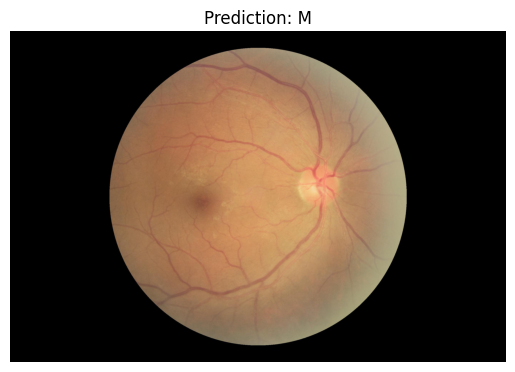

In [2]:
import tensorflow as tf
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# === STEP 1: Define your image path ===
# Example: if you upload a file named "test_image.jpg"
IMG_PATH = "/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/21_right.jpg"
# === STEP 2: Load model ===
model = tf.keras.models.load_model("/kaggle/input/odir_resnet/tensorflow2/default/1/odir_resnet_model.h5")  # or "saved_model_folder/"

# === STEP 3: Prepare image ===
def prepare_image(img_path, target_size=(224, 224)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

img_array = prepare_image(IMG_PATH)

# === STEP 4: Predict ===
pred = model.predict(img_array)[0]

# === STEP 5: Decode prediction ===
class_names = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']  # replace with actual classes
threshold = 0.3
predicted_labels = [class_names[i] for i, p in enumerate(pred) if p > threshold]

# === STEP 6: Display results ===
img = Image.open(IMG_PATH)
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {', '.join(predicted_labels) if predicted_labels else 'None'}")
plt.show()


# VGG Net

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

# === CONFIG ===
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 100

# === PATH SETUP ===
BASE_PATH = "/kaggle/input/ocular-disease-recognition-odir5k"
IMAGE_FOLDER = os.path.join(BASE_PATH, "ODIR-5K", "ODIR-5K", "Training Images")
CSV_PATH = os.path.join(BASE_PATH, "full_df.csv")
WEIGHTS_PATH = "/kaggle/input/vggnet/tensorflow2/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"

# === LOAD DATA ===
df = pd.read_csv(CSV_PATH)
df = df[df['Left-Fundus'].notna()]
df['filename'] = df['Left-Fundus'].str.strip()
df['filepath'] = df['filename'].apply(lambda x: os.path.join(IMAGE_FOLDER, x))
df = df[df['filepath'].apply(os.path.exists)]

# === LABELS ===
label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df[label_cols] = df[label_cols].fillna(0).astype(int)
df['label_list'] = df[label_cols].apply(lambda row: [col for col in label_cols if row[col] == 1], axis=1)

flat_labels = [label for sublist in df['label_list'] for label in sublist]
label_counts = Counter(flat_labels)
df['label_list'] = df['label_list'].apply(lambda labels: [l for l in labels if label_counts[l] >= 2])
df = df[df['label_list'].map(len) > 0].reset_index(drop=True)

# === ENCODE LABELS ===
mlb = MultiLabelBinarizer()
df['encoded'] = mlb.fit_transform(df['label_list']).tolist()

# === SPLIT ===
train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)

# === TF.DATASET PIPELINE ===
def load_image(path, label, training=True):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
    img = preprocess_input(img)
    return img, label

def make_dataset(df, training=True):
    paths = df['filepath'].values
    labels = np.array(df['encoded'].tolist()).astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda x, y: load_image(x, y, training), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)

# === MODEL SETUP ===
base_model = VGG16(include_top=False, weights=None, input_shape=IMG_SIZE + (3,))
base_model.load_weights(WEIGHTS_PATH)
base_model.trainable = True

# Optionally freeze lower layers, fine-tune top layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(mlb.classes_), activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(multi_label=True),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

model.summary()



# === TRAIN ===
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

# === SAVE MODEL FOR DOWNLOAD ===
model.save("/kaggle/working/odir_vgg16.h5")


2025-06-10 12:56:27.488782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749560187.972575      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749560188.105083      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1749560228.128779      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749560228.129501      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,848,072 (56.64 MB)

 Trainable params: 7,212,808 (27.51 MB)

...

Epoch 1/100


I0000 00:00:1749560245.754373      97 service.cc:148] XLA service 0x7997200057e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749560245.756011      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749560245.756036      97 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749560246.537924      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/160 ━━━━━━━━━━━━━━━━━━━━ 1:23:11 31s/step - accuracy: 0.1250 - auc: 0.4315 - loss: 2.2207 - precision: 0.1111 - recall: 0.4242

I0000 00:00:1749560262.276741      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


160/160 ━━━━━━━━━━━━━━━━━━━━ 112s 506ms/step - accuracy: 0.2937 - auc: 0.5860 - loss: 0.4927 - precision: 0.2973 - recall: 0.2041 - val_accuracy: 0.4722 - val_auc: 0.7539 - val_loss: 0.3096 - val_precision: 0.6973 - val_recall: 0.1212
Epoch 2/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 60s 332ms/step - accuracy: 0.4360 - auc: 0.7020 - loss: 0.3353 - precision: 0.5026 - recall: 0.2586 - val_accuracy: 0.4558 - val_auc: 0.7928 - val_loss: 0.3065 - val_precision: 0.6376 - val_recall: 0.2190
Epoch 3/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 57s 311ms/step - accuracy: 0.4878 - auc: 0.7454 - loss: 0.3120 - precision: 0.5562 - recall: 0.2997 - val_accuracy: 0.5160 - val_auc: 0.8134 - val_loss: 0.2841 - val_precision: 0.6014 - val_recall: 0.3336
Epoch 4/100
160/160 ━━━━━━━━━━━━━━━━━━━━ 57s 312ms/step - accuracy: 0.5238 - auc: 0.7855 - loss: 0.2929 - precision: 0.5880 - recall: 0.3430 - val_accuracy: 0.5715 - val_auc: 0.8466 - val_loss: 0.2685 - val_precision: 0.6733 - val_recall: 0.3802
Epoch 5/100
160/160 ━━━━━━━

# Testing images using odir vggnet model

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step


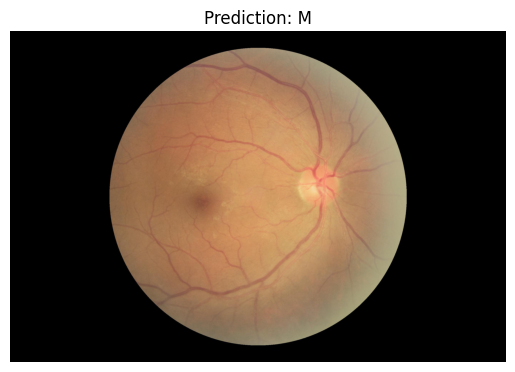

In [2]:
import tensorflow as tf
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

# === STEP 1: Define your image path ===
# Example: if you upload a file named "test_image.jpg"
IMG_PATH = "/kaggle/input/ocular-disease-recognition-odir5k/ODIR-5K/ODIR-5K/Training Images/21_right.jpg"
# === STEP 2: Load model ===
model = tf.keras.models.load_model("/kaggle/input/odir_vggnet/tensorflow2/default/1/odir_vgg16.h5")  # or "saved_model_folder/"

# === STEP 3: Prepare image ===
def prepare_image(img_path, target_size=(224, 224)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

img_array = prepare_image(IMG_PATH)

# === STEP 4: Predict ===
pred = model.predict(img_array)[0]

# === STEP 5: Decode prediction ===
class_names = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']  # replace with actual classes
threshold = 0.3
predicted_labels = [class_names[i] for i, p in enumerate(pred) if p > threshold]

# === STEP 6: Display results ===
img = Image.open(IMG_PATH)
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {', '.join(predicted_labels) if predicted_labels else 'None'}")
plt.show()


# DenseNet 


In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

# === CONFIG ===
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 50  # Adjust as needed

# === PATH SETUP ===
BASE_PATH = "/kaggle/input/ocular-disease-recognition-odir5k"
IMAGE_FOLDER = os.path.join(BASE_PATH, "ODIR-5K", "ODIR-5K", "Training Images")
CSV_PATH = os.path.join(BASE_PATH, "full_df.csv")

# === LOAD DATA ===
df = pd.read_csv(CSV_PATH)
df = df[df['Left-Fundus'].notna()]
df['filename'] = df['Left-Fundus'].str.strip()
df['filepath'] = df['filename'].apply(lambda x: os.path.join(IMAGE_FOLDER, x))
df = df[df['filepath'].apply(os.path.exists)]

# === LABELS ===
label_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df[label_cols] = df[label_cols].fillna(0).astype(int)
df['label_list'] = df[label_cols].apply(lambda row: [col for col in label_cols if row[col] == 1], axis=1)

flat_labels = [label for sublist in df['label_list'] for label in sublist]
label_counts = Counter(flat_labels)
df['label_list'] = df['label_list'].apply(lambda labels: [l for l in labels if label_counts[l] >= 2])
df = df[df['label_list'].map(len) > 0].reset_index(drop=True)

# === ENCODE LABELS ===
mlb = MultiLabelBinarizer()
df['encoded'] = mlb.fit_transform(df['label_list']).tolist()

# === SPLIT ===
train_df, val_df = train_test_split(df, test_size=0.2, random_state=SEED)

# === TF.DATA PIPELINE ===
def load_image(path, label, training=True):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
    img = preprocess_input(img)
    return img, label

def make_dataset(df, training=True):
    paths = df['filepath'].values
    labels = np.array(df['encoded'].tolist()).astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda x, y: load_image(x, y, training), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(1000)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)

# === MODEL: DenseNet121 ===
base_model = DenseNet121(include_top=False, weights='imagenet', input_shape=IMG_SIZE + (3,))
base_model.trainable = True

# Fine-tune last few layers only
for layer in base_model.layers[:-10]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(mlb.classes_), activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(multi_label=True),
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

model.summary()

# === TRAIN ===
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

# === SAVE MODEL ===
model.save("/kaggle/working/odir_densenet121.h5")


2025-06-11 02:29:37.850562: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749608978.038500      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749608978.093193      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1749609004.301236      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749609004.302094      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)             │ (None, 7, 7, 1024)          │       7,037,504 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,301,960 (27.85 MB)

...

Epoch 1/50


I0000 00:00:1749609038.975890      99 service.cc:148] XLA service 0x7dd09c002110 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749609038.976634      99 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749609038.976656      99 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749609042.241611      99 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/160 ━━━━━━━━━━━━━━━━━━━━ 2:07:45 48s/step - accuracy: 0.0625 - auc: 0.5547 - loss: 0.7350 - precision: 0.1236 - recall: 0.2821

I0000 00:00:1749609056.607625      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


160/160 ━━━━━━━━━━━━━━━━━━━━ 129s 509ms/step - accuracy: 0.2548 - auc: 0.5453 - loss: 0.4546 - precision: 0.2627 - recall: 0.1941 - val_accuracy: 0.3870 - val_auc: 0.6984 - val_loss: 0.3333 - val_precision: 0.5152 - val_recall: 0.0905
Epoch 2/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 43s 232ms/step - accuracy: 0.3648 - auc: 0.6501 - loss: 0.3484 - precision: 0.4360 - recall: 0.1718 - val_accuracy: 0.4550 - val_auc: 0.7509 - val_loss: 0.3078 - val_precision: 0.6587 - val_recall: 0.1285
Epoch 3/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 84s 245ms/step - accuracy: 0.4344 - auc: 0.6976 - loss: 0.3259 - precision: 0.5140 - recall: 0.2141 - val_accuracy: 0.5145 - val_auc: 0.7737 - val_loss: 0.3010 - val_precision: 0.6728 - val_recall: 0.1698
Epoch 4/50
160/160 ━━━━━━━━━━━━━━━━━━━━ 44s 235ms/step - accuracy: 0.4775 - auc: 0.7251 - loss: 0.3156 - precision: 0.5555 - recall: 0.2454 - val_accuracy: 0.5043 - val_auc: 0.7922 - val_loss: 0.2926 - val_precision: 0.6706 - val_recall: 0.2290
Epoch 5/50
160/160 ━━━━━━━━━━━

# Testing images using odir_Densenet model